# Forecast Behaviour Depending on IOD State

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import ocha_stratus as stratus
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

import re
from src.utils import *
from src.datasources.era5 import fetch_era5_data

In [3]:
import calendar

season_months = [10, 11, 12]
start_date = pd.Timestamp("1998-01-01")
end_date = pd.Timestamp("2025-12-31")

In [4]:
iso3 = "KEN"
blob_name = "ds-aa-ken-drought/processed/cleaned_hindcasts.parquet"

In [5]:
ken_adm = stratus.codab.load_codab_from_fieldmaps(iso3, admin_level=1)
ken_adm0 = stratus.codab.load_codab_from_fieldmaps(iso3, admin_level=0)

In [6]:
hindcast = stratus.load_parquet_from_blob(
    blob_name, stage="dev", container_name="projects"
)
hindcast

,lat,lon,value,C,T,clim_prob,clim_prob_type,issue_month
0,5.75,33.25,38.599842,1,2005-10-01,0.2004542,below,July
1,5.75,33.75,37.861221,1,2005-10-01,0.2004542,below,July
2,5.75,34.25,37.609367,1,2005-10-01,0.2004542,below,July
3,5.75,34.75,41.814418,1,2005-10-01,0.2004542,below,July
4,5.75,35.25,39.147652,1,2005-10-01,0.2004542,below,July
...,...,...,...,...,...,...,...,...
391,-4.75,39.75,10.949339,3,2016-10-01,0.4641436,above,September
392,-4.75,40.25,5.071429,3,2016-10-01,0.4641436,above,September
393,-4.75,40.75,3.178571,3,2016-10-01,0.4641436,above,September
394,-4.75,41.25,6.178571,3,2016-10-01,0.4641436,above,September


In [7]:
hindcast["year"] = pd.to_datetime(hindcast["T"]).dt.year
median_prob = (
    hindcast[hindcast["C"] == "1"]
    .groupby(["year", "issue_month"])["value"]
    .median()
    .reset_index()
)
median_prob.tail()

,year,issue_month,value
31,2015,July,5.452876
32,2015,September,2.082183
33,2016,August,47.403826
34,2016,July,52.398900
35,2016,September,54.222760


In [8]:
lead_time = median_prob.pivot(
    index="year", columns="issue_month", values="value"
).reset_index()
lead_time["lt_variability"] = lead_time[["July", "August", "September"]].max(
    axis=1
) - lead_time[["July", "August", "September"]].min(axis=1)
lead_time["lt_std"] = lead_time[["July", "August", "September"]].std(axis=1)
lead_time

issue_month,year,August,July,September,lt_variability,lt_std
0,2005,33.779839,38.017330,34.908103,4.237491,2.194562
1,2006,16.397957,13.347159,14.328858,3.050797,1.557362
2,2007,26.790575,27.577520,23.844068,3.733452,1.968072
3,2008,26.837775,16.235928,23.970345,10.601847,5.483954
4,2009,22.406923,11.346910,17.184949,11.060014,5.532866
5,2010,43.431829,40.268891,47.209036,6.940145,3.474600
6,2011,8.636755,15.407608,15.072830,6.770853,3.816184
7,2012,12.902915,12.736964,10.828262,2.074653,1.152886
8,2013,38.894283,36.011533,29.694952,9.199332,4.705266
9,2014,18.253311,20.200895,20.226870,1.973558,1.132011


In [9]:
blob_name_iod = "ds-aa-ken-drought/raw/iod.csv"

In [10]:
df = stratus.load_csv_from_blob(blob_name_iod, stage="dev", container_name="projects")

In [11]:
# parse dates
df["Start"] = pd.to_datetime(df["Start"], format="%Y%m%d")
df["End"] = pd.to_datetime(df["End"], format="%Y%m%d")

# flag negative weeks
df["neg_iod"] = df["Value"] <= -0.4

# identify consecutive runs
df["run_id"] = (df["neg_iod"] != df["neg_iod"].shift()).cumsum()

# keep only negative runs
neg_runs = df[df["neg_iod"]].copy()

# count duration (weeks) per run
run_lengths = neg_runs.groupby("run_id").size()

# runs lasting at least 8 weeks
persistent_runs = run_lengths[run_lengths >= 8].index

# extract persistent negative IOD periods
iod_negative_persistent = neg_runs[neg_runs["run_id"].isin(persistent_runs)]

iod_negative_persistent[["Start", "End", "Value"]]

,Start,End,Value
104,2010-07-26,2010-08-01,-0.43
105,2010-08-02,2010-08-08,-0.52
106,2010-08-09,2010-08-15,-0.58
107,2010-08-16,2010-08-22,-0.59
108,2010-08-23,2010-08-29,-1.05
...,...,...,...
899,2025-11-03,2025-11-09,-1.57
900,2025-11-10,2025-11-16,-0.99
901,2025-11-17,2025-11-23,-0.60
902,2025-11-24,2025-11-30,-0.46


In [12]:
summary = (
    iod_negative_persistent.groupby("run_id")
    .agg(
        start_date=("Start", "min"),
        end_date=("End", "max"),
        duration_weeks=("Value", "size"),
        min_dmi=("Value", "min"),
    )
    .reset_index(drop=True)
)

summary

,start_date,end_date,duration_weeks,min_dmi
0,2010-07-26,2010-10-31,14,-1.34
1,2016-06-20,2016-10-23,18,-1.46
2,2020-08-10,2020-10-04,8,-0.96
3,2021-07-12,2021-11-28,20,-0.98
4,2022-06-27,2022-11-13,20,-1.45
5,2025-07-21,2025-12-07,20,-1.94


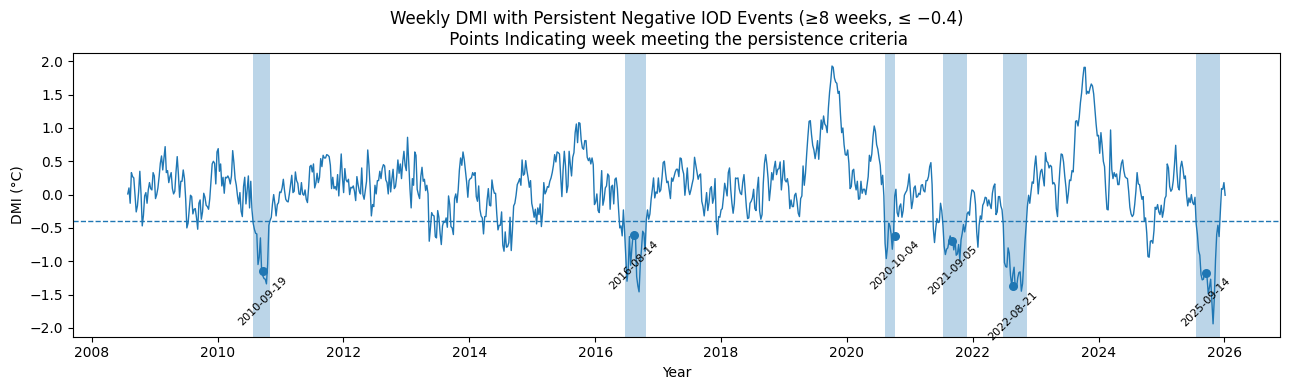

In [13]:
fig, ax = plt.subplots(figsize=(13, 4))

# full time series
ax.plot(df["Start"], df["Value"], linewidth=1)
ax.axhline(-0.4, linestyle="--", linewidth=1)

# shade persistent negative IOD periods
for run_id, g in iod_negative_persistent.groupby("run_id"):
    ax.axvspan(g["Start"].min(), g["End"].max(), alpha=0.3)

# identify the activation week (8th consecutive negative week)
activation_points = iod_negative_persistent.assign(
    week_in_run=iod_negative_persistent.groupby("run_id").cumcount() + 1
).query("week_in_run == 8")

# plot dots at activation point
ax.scatter(
    activation_points["End"],
    activation_points["Value"],
    zorder=4,
    s=30,
)

# label dates
for _, r in activation_points.iterrows():
    ax.text(
        r["End"],
        r["Value"] - 0.05,
        r["End"].strftime("%Y-%m-%d"),
        ha="center",
        va="top",
        fontsize=8,
        rotation=45,
    )

ax.set_xlabel("Year")
ax.set_ylabel("DMI (°C)")
ax.set_title(
    "Weekly DMI with Persistent Negative IOD Events (≥8 weeks, ≤ −0.4)\n Points Indicating week meeting the persistence criteria"
)

plt.tight_layout()
plt.show()

In [14]:
lead_time["plot_date"] = pd.to_datetime(lead_time["year"].astype(str) + "-01-01")

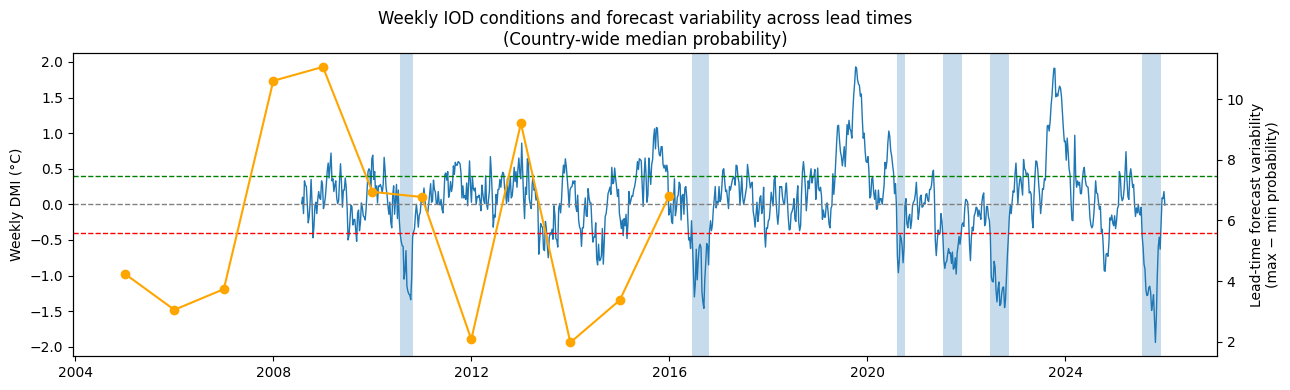

In [15]:
fig, ax = plt.subplots(figsize=(13, 4))

# -------------------------
# weekly DMI (left axis)
# -------------------------
ax.plot(df["Start"], df["Value"], linewidth=1)
ax.axhline(0, linestyle="--", linewidth=1, color="gray")
ax.axhline(-0.4, linestyle="--", linewidth=1, color="red")
ax.axhline(0.4, linestyle="--", linewidth=1, color="green")

# shade negative IOD periods
for run_id, g in iod_negative_persistent.groupby("run_id"):
    ax.axvspan(g["Start"].min(), g["End"].max(), alpha=0.25)

ax.set_ylabel("Weekly DMI (°C)")

# -------------------------
# forecast variability (right axis)
# -------------------------
ax2 = ax.twinx()

ax2.plot(
    lead_time["plot_date"],
    lead_time["lt_variability"],
    marker="o",
    linewidth=1.5,
    color="orange",
)

ax2.set_ylabel("Lead-time forecast variability\n(max − min probability)")

# -------------------------
# title
# -------------------------
ax.set_title(
    "Weekly IOD conditions and forecast variability across lead times\n"
    "(Country-wide median probability)"
)

plt.tight_layout()
plt.show()